In [83]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res, read_ripser_result
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle
from utils.pd_utils import get_life_times
from utils.pd_utils import get_persistent_feature_id, get_persistent_cycle, compute_outlier_scores, filter_diagram
from utils.confidence_utils import median_max_life_time, get_bottleneck_dist
from utils.passing_cells_utils import distribution_max

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.confidence import fig_bottleneck, fig_bottleneck_max

from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [84]:
root_path = get_path("data")
fig_path = get_path("figures")
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

# embedding+mask loading if procrustes

In [34]:
# embd_tasic_purple = np.load(os.path.join(root_path, "embd_after_procrustes", "embd_tasic_purple.npy"))
embd_tasic_purple = np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_tasic_purple.npy"))


## embedding loading and mask making if not procrustes

In [ ]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
file_name = os.path.join(root_path,
                         "tasic",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [91]:
_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)

In [93]:
mask_Vip = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Vip")
mask_Sncg = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sncg")
mask_Serpinf1 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Serpinf1")
mask_Lamp5 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Lamp5")

mask_Lamp5_Lhx6 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Lamp5 Lhx6")  
mask_lamp5_wo_Lhx6 = [a and not b for a, b in zip(mask_Lamp5, mask_Lamp5_Lhx6)]
mask_purple = mask_Vip | mask_Sncg | mask_Serpinf1 | mask_lamp5_wo_Lhx6

In [8]:
print("dataset size of purple is ", sum(mask_purple))

dataset size of purple is  5289


In [ ]:
dataset = "tasic_purple_lamp5"
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with tasic_purple_lamp5 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


# most persistent

## shuffle_pts

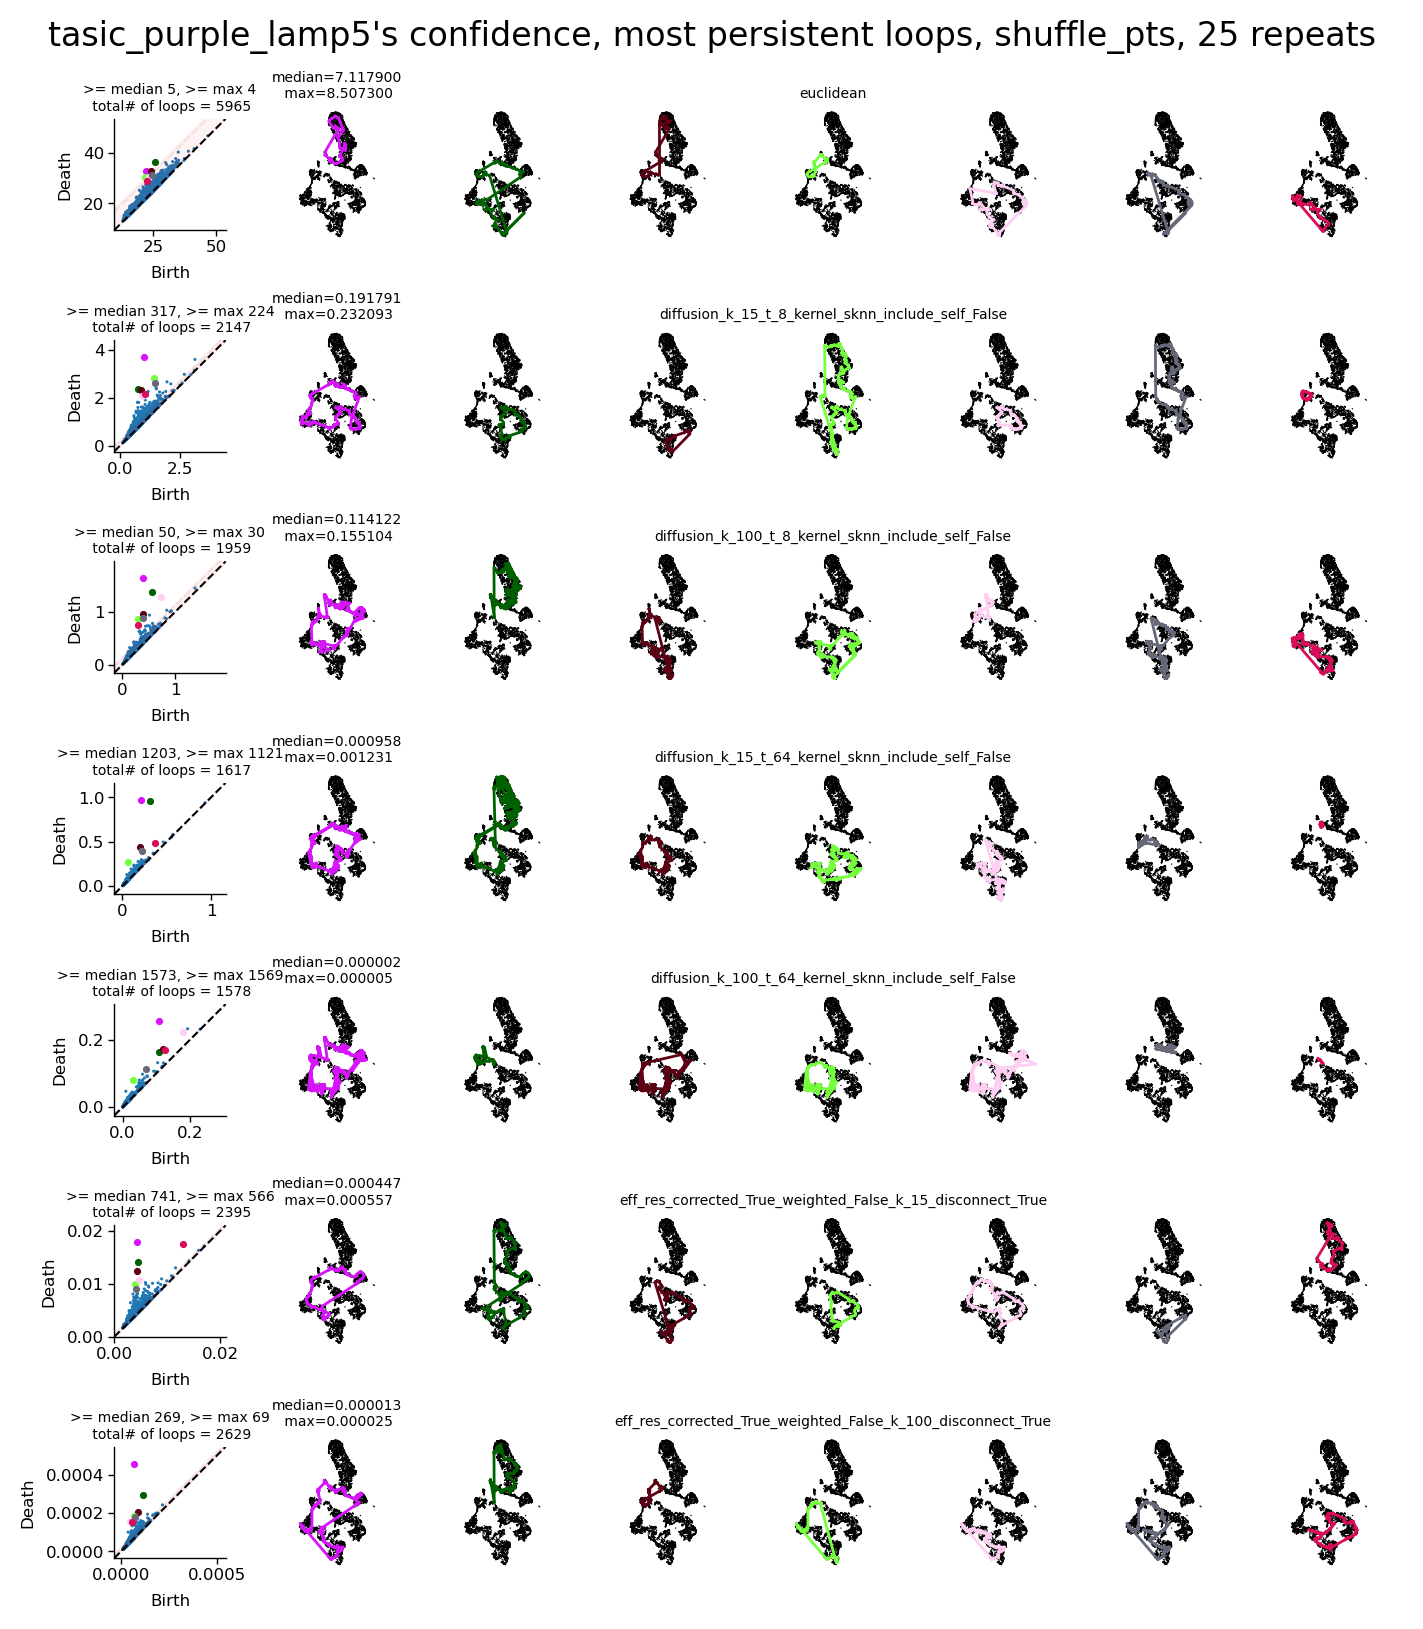

In [ ]:
fig_most_persistent(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_purple , method="shuffle_pts", save = True)

## bootstrap

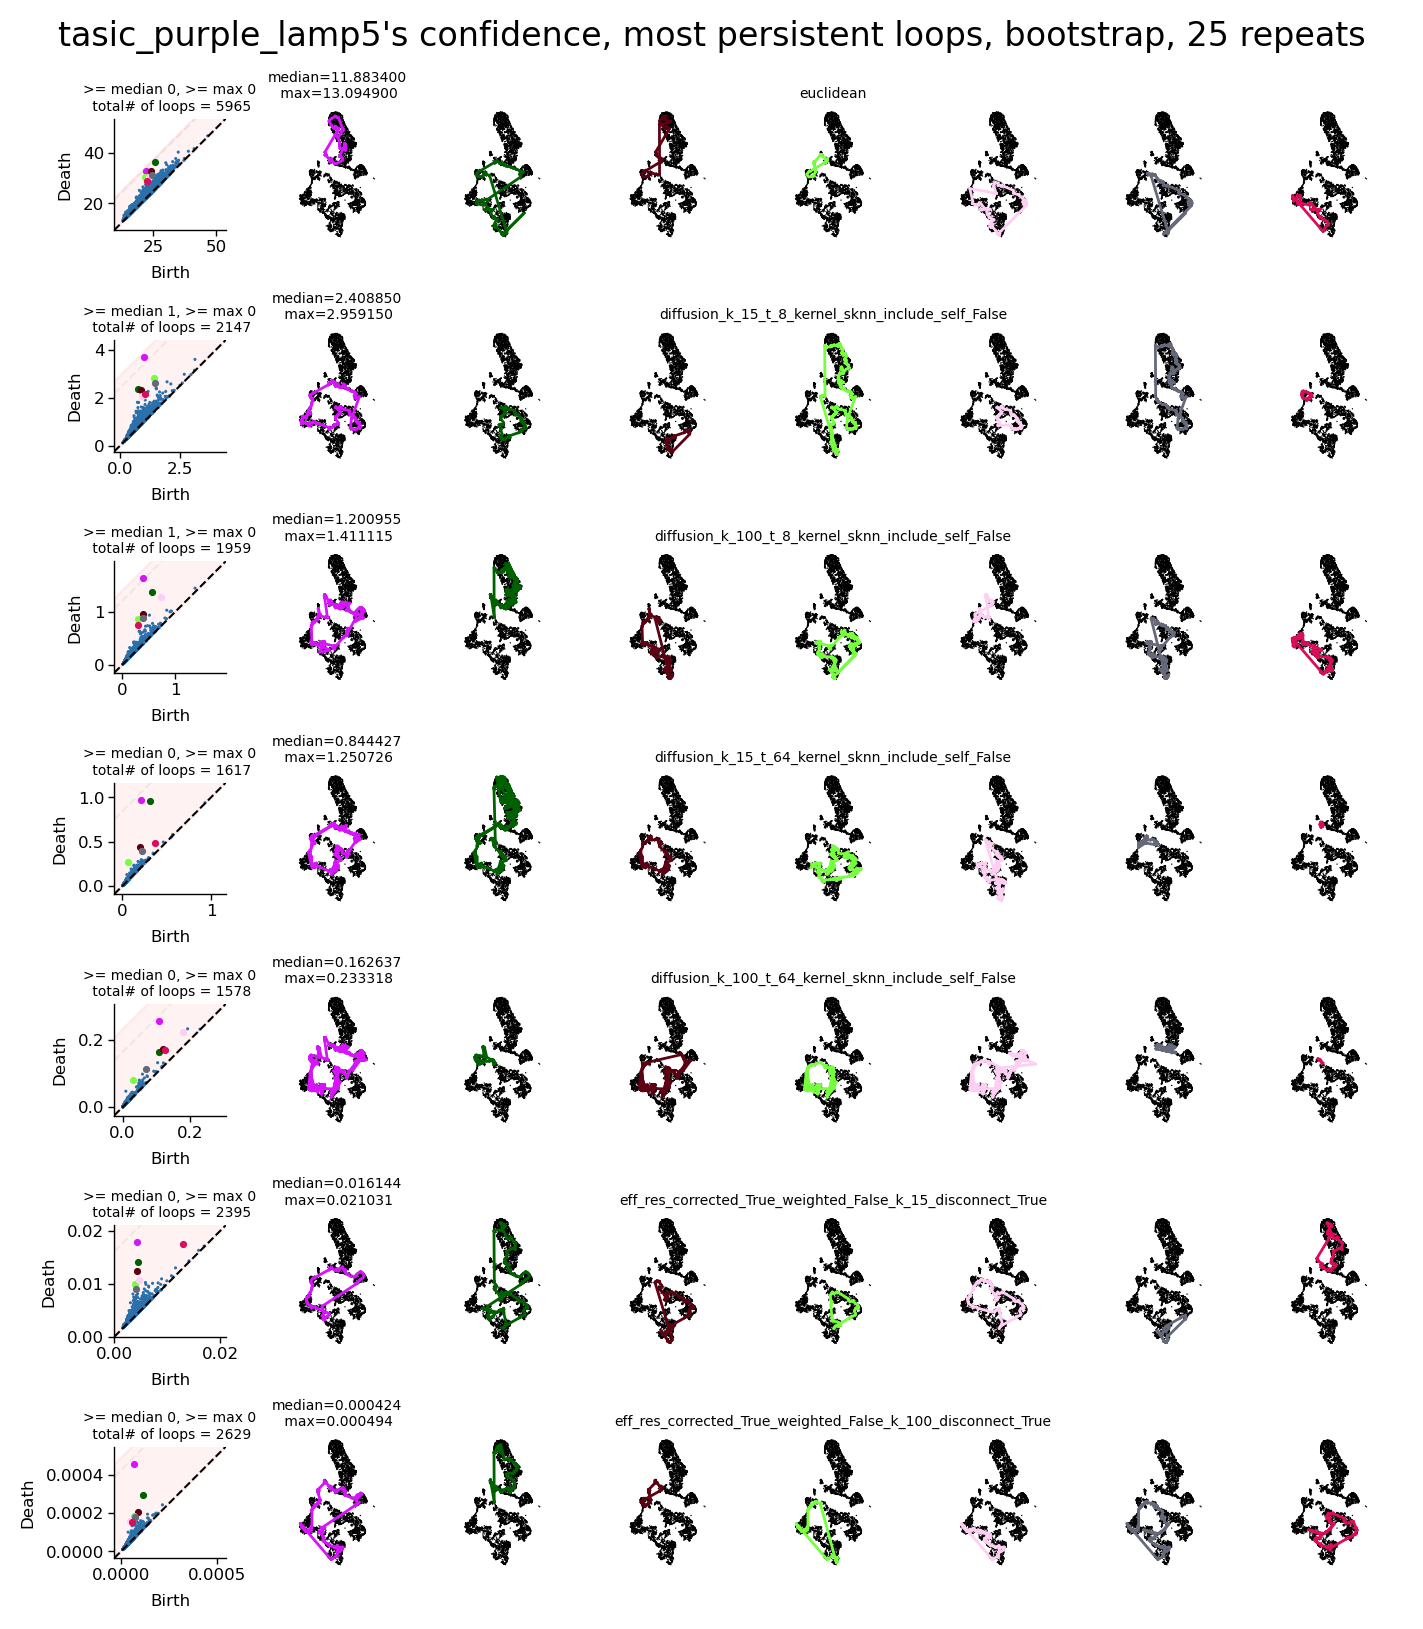

In [ ]:
fig_most_persistent(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_purple , method="bootstrap", save = True)

# bottleneck

## shuffle_pts

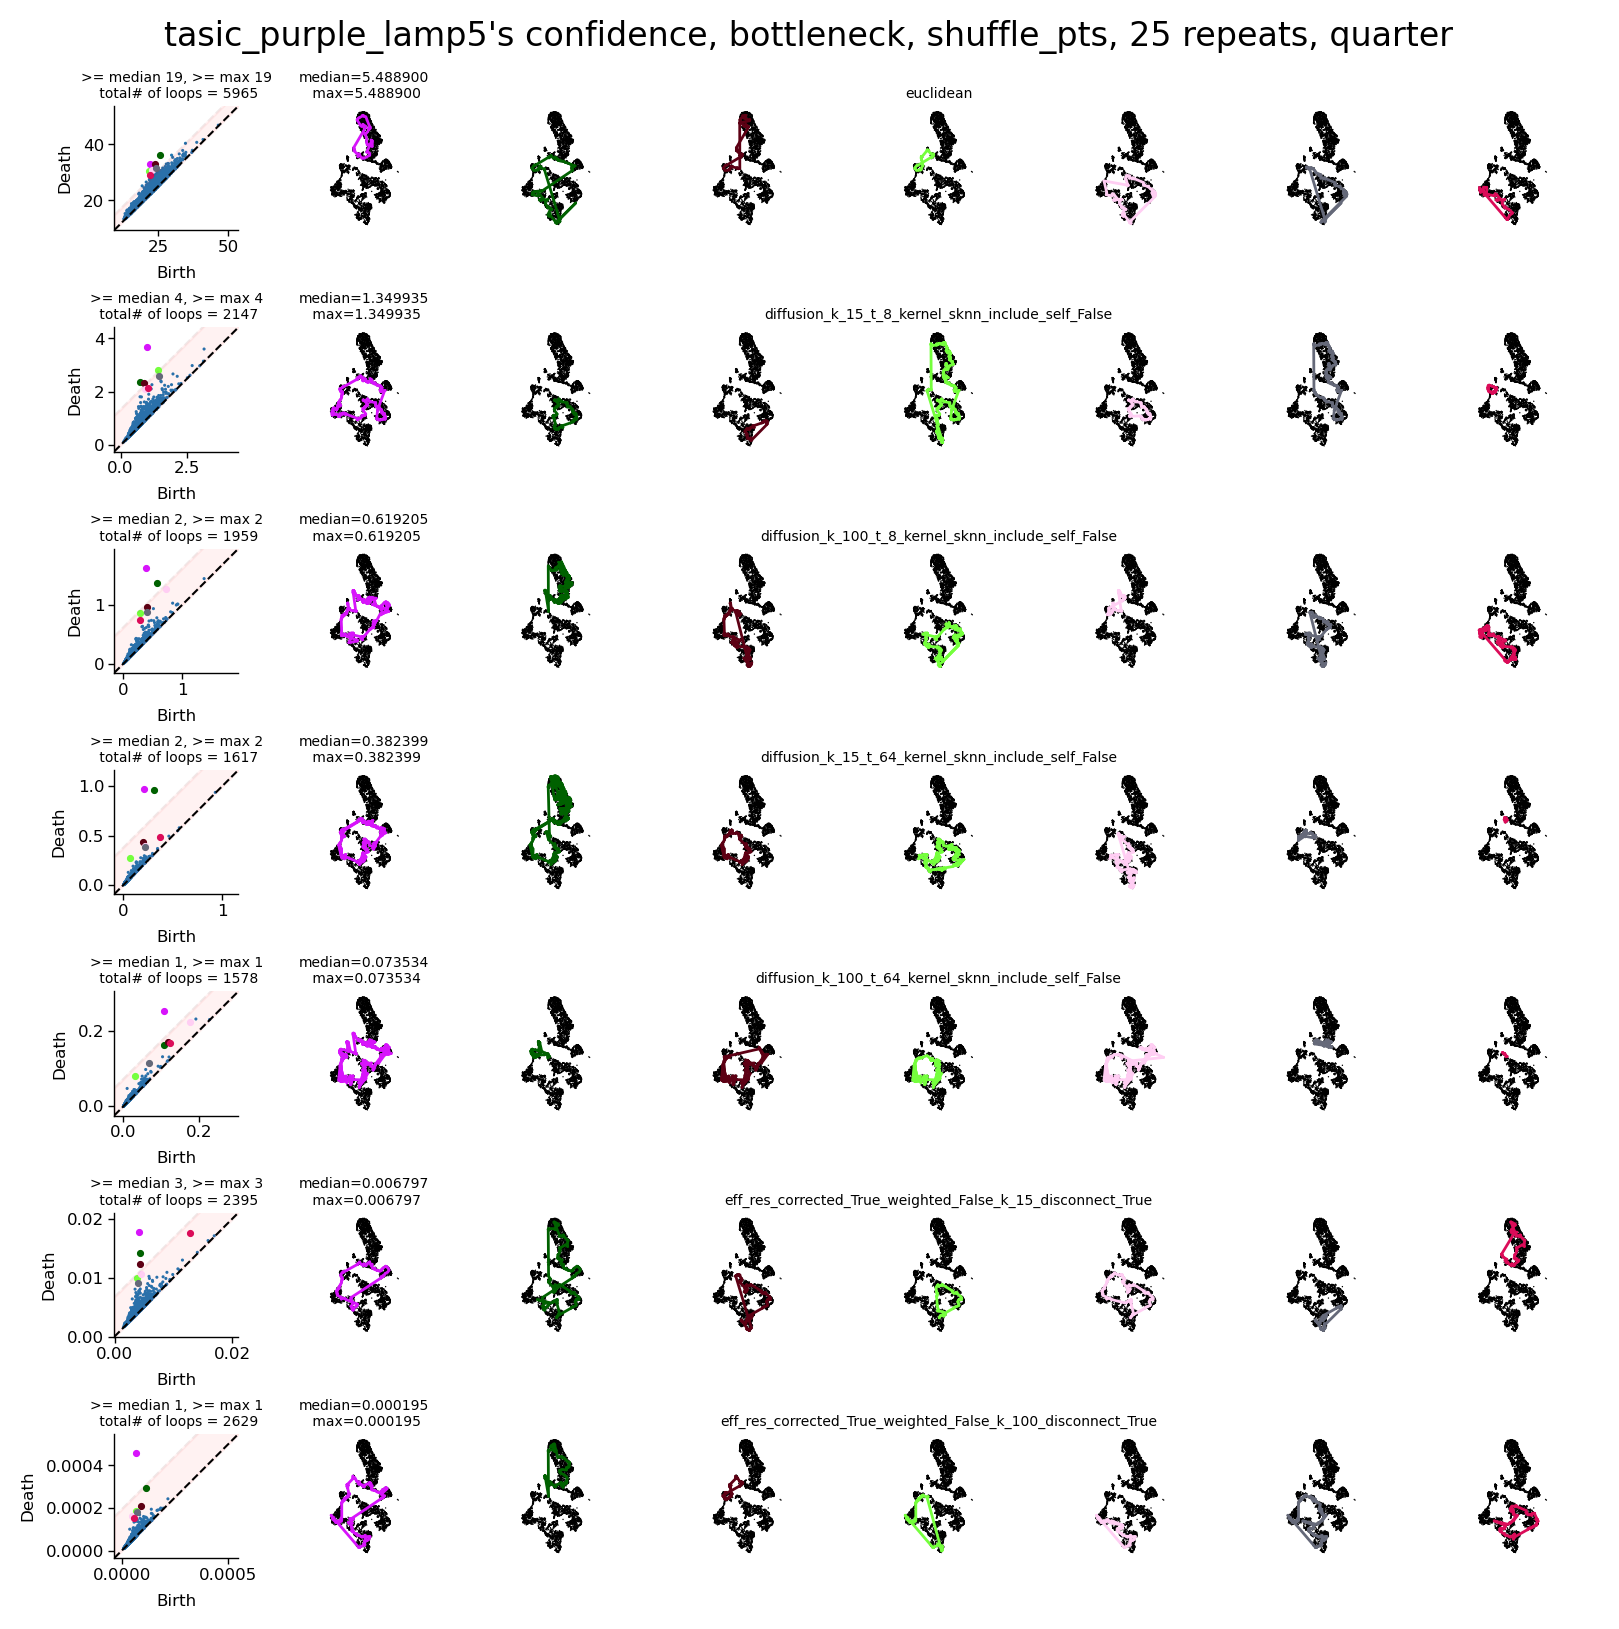

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_purple , method="shuffle_pts", save = True)

## bootstrap

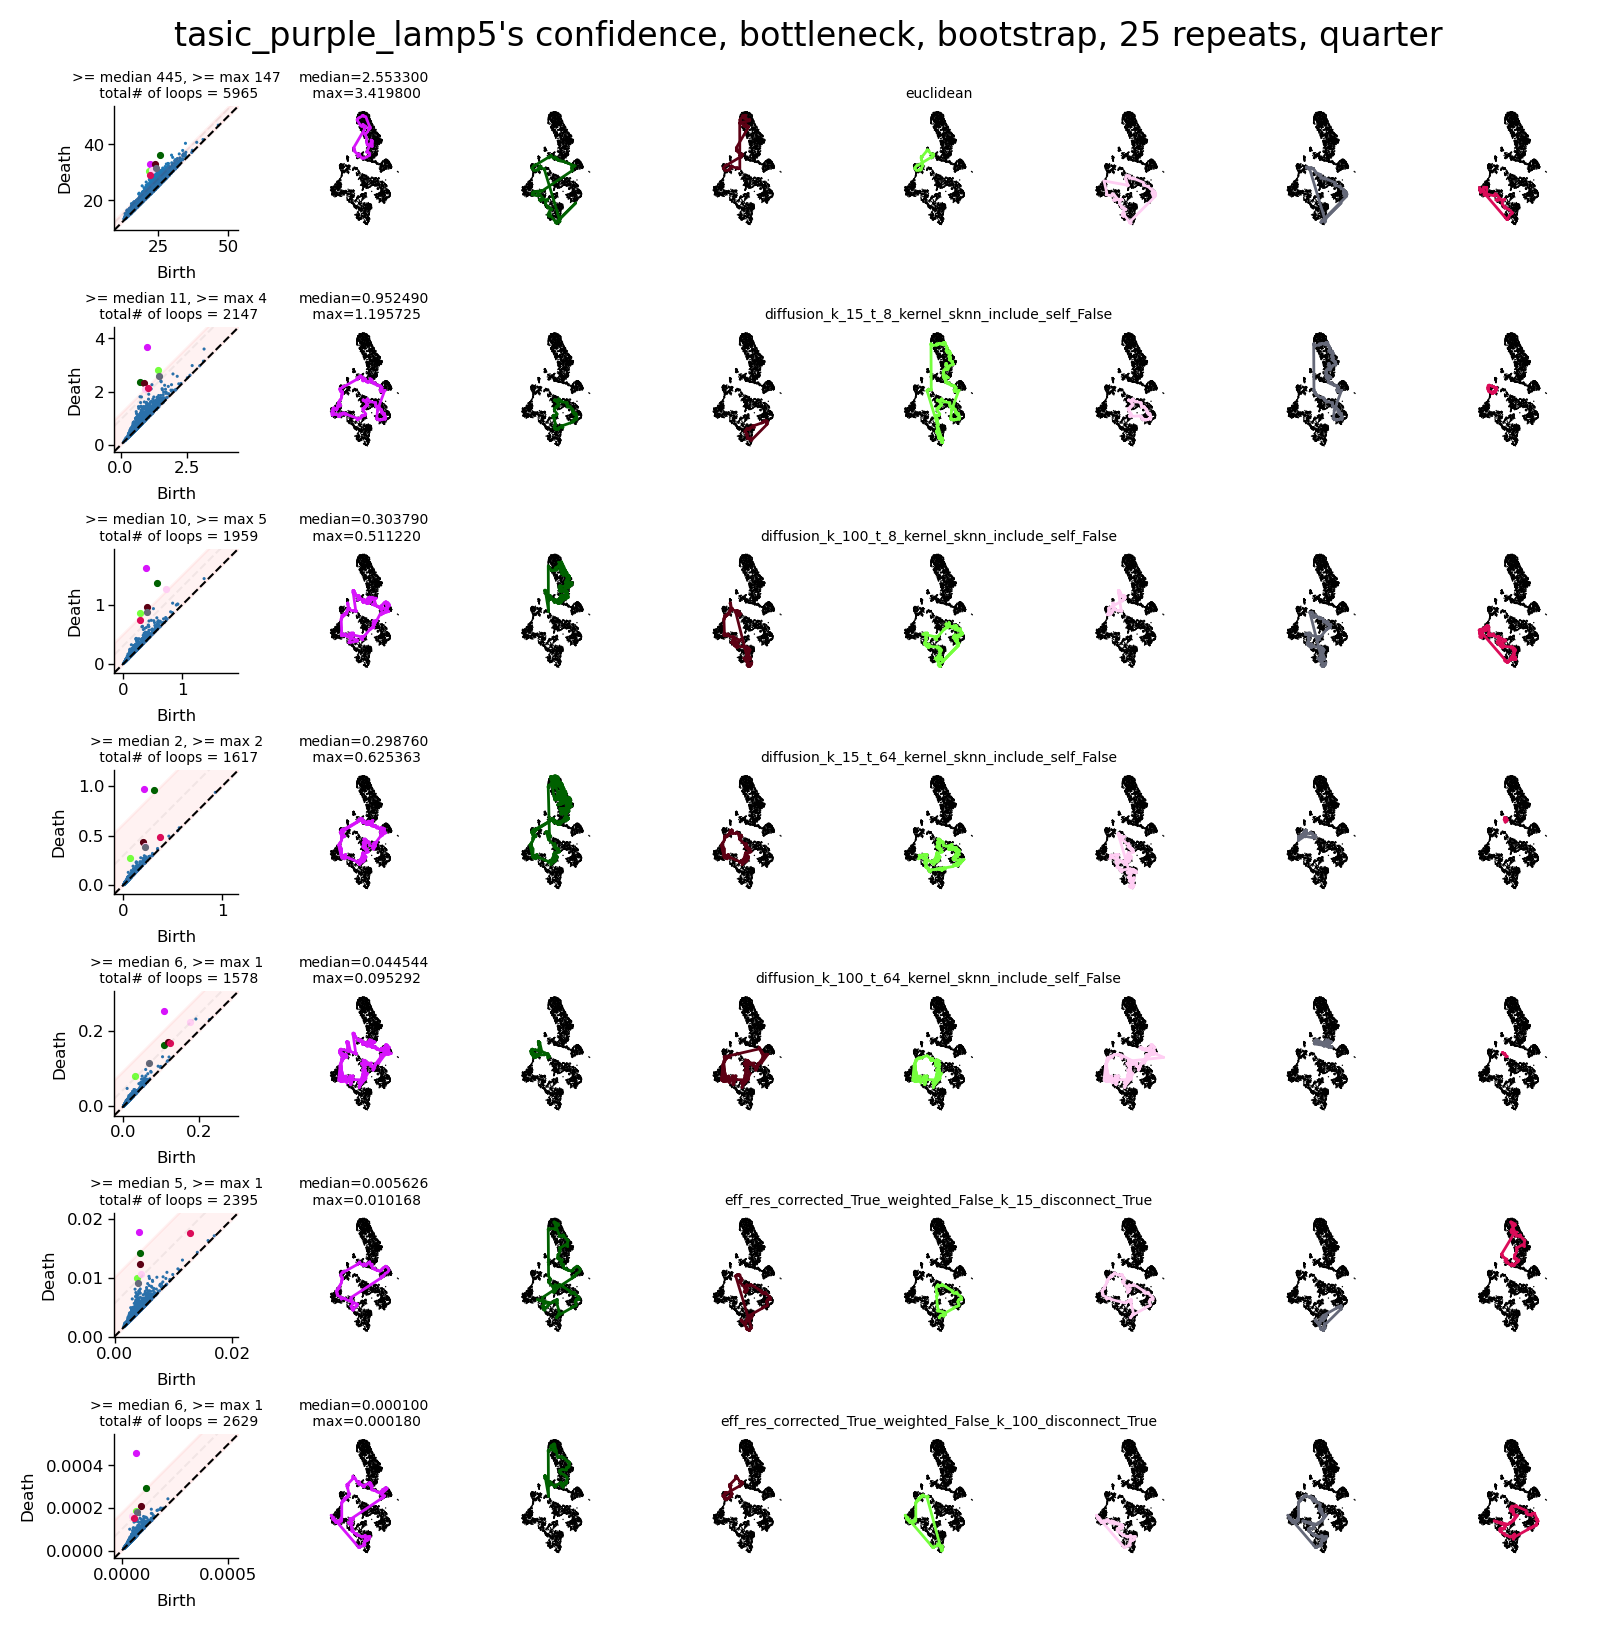

In [ ]:
fig_bottleneck(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_purple , method="bootstrap", save = True)

# fig_bottleneck_max of bootstrap

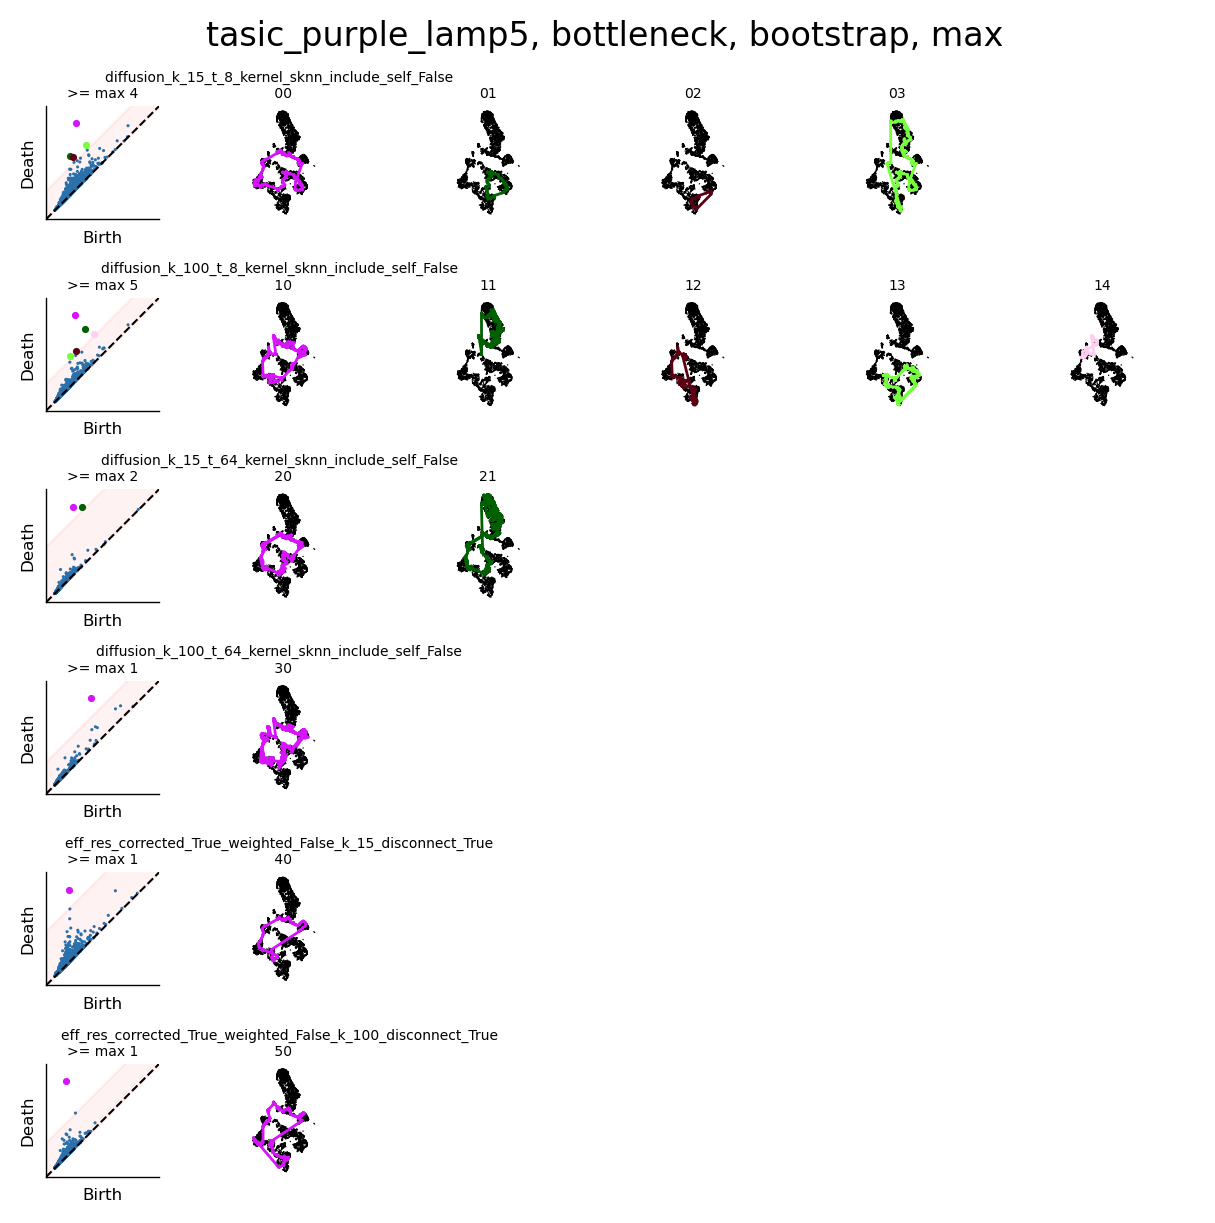

In [ ]:
geq_maxs = fig_bottleneck_max(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_purple , method="bootstrap", save = True)

# save distribution dist

In [ ]:
_, _, _, _, yao_d = load_dataset(root_path, "yao_smart", k=k)
cluster_purple = [cluster for i, cluster in enumerate(yao_d["clusterNames"]) 
                  if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]

In [ ]:
tasic_purple_dict = distribution_max(all_res, cell_group_name= "tasic_purple_lamp5", clusters = cluster_purple, full_d = full_d, mask = mask_purple, geq_maxs = geq_maxs)

In [ ]:
tasic_purple_dict["idx"]

['00',
 '01',
 '02',
 '03',
 '10',
 '11',
 '12',
 '13',
 '14',
 '20',
 '21',
 '30',
 '40',
 '50']

In [ ]:
len(tasic_purple_dict["idx"])

14

In [ ]:
save_dict(tasic_purple_dict, os.path.join(get_path("data"),"final_dist_bottleneck_max", "dist_tasic_purple.pkl"))

# fig_bottleneck_rescale of bootstrap

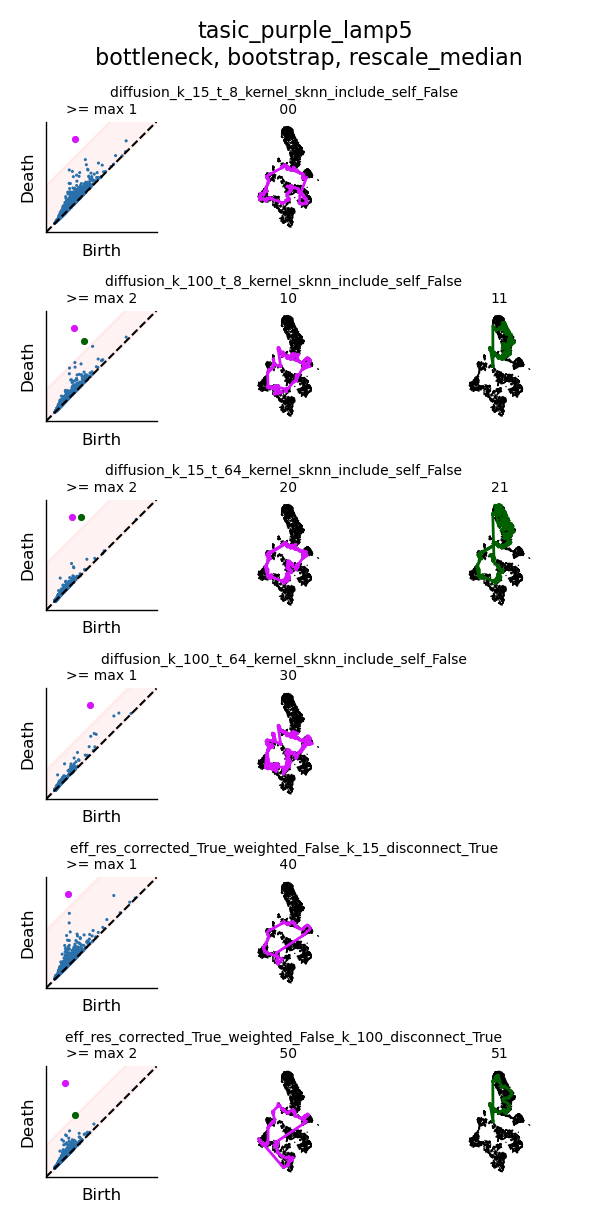

In [ ]:
geq_maxs = fig_bottleneck_rescale(all_res,  dataset=dataset, embd_n_mask =  embd_tasic_purple , method="bootstrap", save = True)

In [ ]:
def get_life_geq_rescale(all_res, dataset, method, ratio = "quarter"):
    root_path = get_path("data")
    geq_rescales_max = []
    life_rescales_max = []
    geq_rescales_median = []
    life_rescales_median = []
    for i, distance in enumerate(list(all_res.keys())):
        for j, full_dist in enumerate(all_res[distance]):
            res = all_res[distance][full_dist]
            life_array = all_res[distance][full_dist]["dgms"][1]
            reference_life_long = life_array[:,1] - life_array[:,0]
            
            tryit = load_dict(os.path.join(root_path, dataset, f"bottleneck_match_{method}_{ratio}_{full_dist}.pkl"))
            bottleneck_dists = list(tryit.values())[0]
            matchs = tryit['matching']
            rescale_bottlenecks = []
            for r in range(len(matchs)):
                max_idx = np.argmax(matchs[r][:,2])
                if np.max(matchs[r][:,2])!= bottleneck_dists[r]:
                    print(f"max not correct, {np.max(matchs[r][:,2])}, {bottleneck_dists[r]}")
                    rescale_bottleneck = -1
                elif matchs[r][max_idx, 0] == -1 or matchs[r][max_idx, 1] == -1:
                    rescale_bottleneck = 2 * bottleneck_dists[r]
                elif matchs[r][max_idx, 0] != -1 and matchs[r][max_idx, 1] != -1:
                    if ratio == "quarter":
                        the_threshold = int(np.floor(len(reference_life_long)/4))
                    filtered_ref_dgm, _ = filter_diagram(res, dim=1,  n=the_threshold)
                    ref_xy = filtered_ref_dgm["dgms"][1][max_idx,:]
                    
                    file_name = os.path.join(root_path,
                            dataset,
                            f"{dataset}_seed_0_{method}_{r}_{full_dist}_rep")
                    repeated_dgm = read_ripser_result(file_name)
                    # plot_diagrams_alpha(repeated_dgm["dgms"][1], ax=ax, size=5, color = "blue", alpha = 1)
                    filtered_dgm, _ = filter_diagram(repeated_dgm, dim=1, n=the_threshold)
                    rep_xy = filtered_dgm["dgms"][1][max_idx,:]
                    rescale_bottleneck = np.linalg.norm(ref_xy - rep_xy)*np.sqrt(2)
                rescale_bottlenecks.append(rescale_bottleneck)
            # print(rescale_bottlenecks)
            # print(np.where(rescale_bottlenecks == -1))
        
            life_rescale_max = np.max(rescale_bottlenecks)
            life_rescales_max.append(life_rescale_max)
            geq_rescale_max = np.sum(np.array(reference_life_long) >= life_rescale_max)
            geq_rescales_max.append(geq_rescale_max)
            
            life_rescale_median = np.median(rescale_bottlenecks)
            life_rescales_median.append(life_rescale_median)
            geq_rescale_median = np.sum(np.array(reference_life_long) >= life_rescale_median)
            geq_rescales_median.append(geq_rescale_median)
            
 
    return life_rescales_median, geq_rescales_median #life_rescales_max, geq_rescales_max, 

In [ ]:
def fig_bottleneck_rescale(all_res, dataset, embd_n_mask, method, ratio = "quarter", save=None):
    style_file = "utils.style"
    plt.style.use(style_file)
    
    root_path = get_path("data")
    fig_path = get_path("figures")
    
    life_maxs, geq_maxs = get_life_geq_rescale(all_res, dataset, method, ratio)
    
    # n_cols = max(max(geq_maxs)+1, 4)
    n_cols = max(geq_maxs)+1
    n_exp = sum([len(all_res[distance]) for distance in all_res.keys()])

    width_ratios = [0.75] + [1] * (n_cols-1)
    
    tab10 = matplotlib.colormaps.get_cmap("tab10")
    existing_colors = [tab10(1)]
    colors = glasbey.extend_palette(existing_colors, n_cols+len(existing_colors)+2)[len(existing_colors)+1:]
    
    fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(n_cols, n_exp), constrained_layout=True, width_ratios=width_ratios)
    seed = 0
    row = 0
    for i, distance in enumerate(list(all_res.keys())):
        for j, full_dist in enumerate(all_res[distance]):
            res = all_res[distance][full_dist]
            
            ax[row][0].set_title(f">= max {geq_maxs[row]}", fontsize = 5)
            plot_dgm_loops(res, embd_n_mask, y="k", n_loops=0, confidence = life_maxs[row], ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=False)
            
            life_times_loops = get_life_times(res, dim=1)
            loop_idx_sorted = np.argsort(life_times_loops)[::-1]
            
            for k in range(1, n_cols):
                ax[row][k].set_title(f"{row}{k-1}", fontsize=5)
                loop_id = loop_idx_sorted[k-1]
                plot_edges_on_scatter(ax=ax[row][k],
                                 edge_idx=res["cycles"][1][loop_id],
                                 x=embd_n_mask,
                                 color=colors[k],
                                  linewidth=1)
                if k < geq_maxs[row]+1:
                    ax[row][0].scatter(*res["dgms"][1][loop_id].T, c=colors[k], s=10)
                else:
                    # ax[row][k].axis("off")
                    ax[row][k].remove()
            
            
            if geq_maxs[row]>0:
                ax[row][1].set_title(f"{full_dist}  \n {row}0 ", fontsize=5)
            ax[row][0].legend().set_visible(False)
            
            for n in range(1, n_cols):
                if dataset == "yao_smart_purple":
                    ax[row][n].set_xlim(-20, 40)
                    ax[row][n].set_ylim(5, 85)
                elif dataset == "yao_smart_purple":
                    ax[row][n].set_xlim(20, 80)
                    ax[row][n].set_ylim(-70, 40)
                elif "10x" in dataset and "purple" in dataset:
                    ax[row][n].set_xlim(-65, -15)
                    ax[row][n].set_ylim(25, 70)
                elif "10x" in dataset and "purple" in dataset:
                    ax[row][n].set_xlim(-90, -40)
                    ax[row][n].set_ylim(-30, 30)
            
            
            ax[row][0].set_xticks([])
            ax[row][0].set_yticks([])
            # ax[row][0].set_ylabel("Death")

            row+=1
    fig.suptitle(f"{dataset}\n bottleneck, {method}, rescale_median", fontsize = 8)       

    plt.show()
    if save is True:
        fig.savefig(os.path.join(fig_path, f"Bottleneck_rescale_median_{dataset}_{method}.png"), dpi=300)
    elif type(save) == str:
        fig.savefig(os.path.join(fig_path, f"{save}.png"), dpi=300)
    
    return geq_maxs

# fig_bottleneck_median_scale

In [ ]:
dataset = "tasic_purple_lamp5"


_, _, _, _, yao_d = load_dataset(root_path, "yao_smart", k=k)
cluster_purple = [cluster for i, cluster in enumerate(yao_d["clusterNames"]) 
                  if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]

_, _, _, _, full_d = load_dataset(root_path, "tasic", k=k)
mask_Vip = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Vip")
mask_Sncg = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Sncg")
mask_Serpinf1 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Serpinf1")
mask_Lamp5 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Lamp5")

mask_Lamp5_Lhx6 = np.char.startswith(full_d["clusterNames"][full_d['clusters']], "Lamp5 Lhx6")  
mask_lamp5_wo_Lhx6 = [a and not b for a, b in zip(mask_Lamp5, mask_Lamp5_Lhx6)]
mask_purple = mask_Vip | mask_Sncg | mask_Serpinf1 | mask_lamp5_wo_Lhx6

all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

Done with tasic_purple_lamp5 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


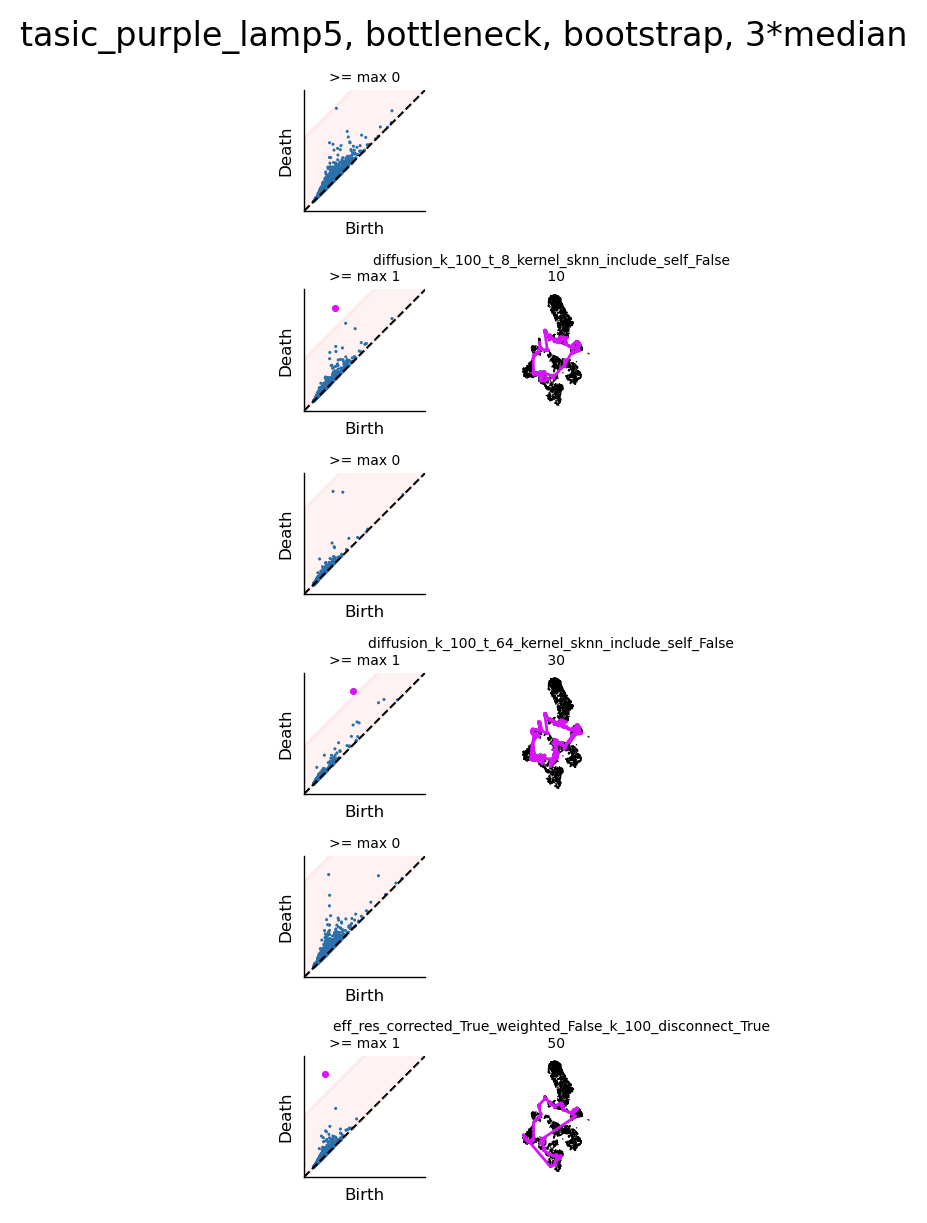

In [ ]:
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  embd_tasic_purple, method="bootstrap", scale = 3, save = False)
dist = distribution_max(all_res, cell_group_name= dataset, clusters = cluster_purple, full_d = full_d, mask = mask_purple, geq_maxs = geq_maxs)
save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_tasic_purple_scale_3.pkl"))

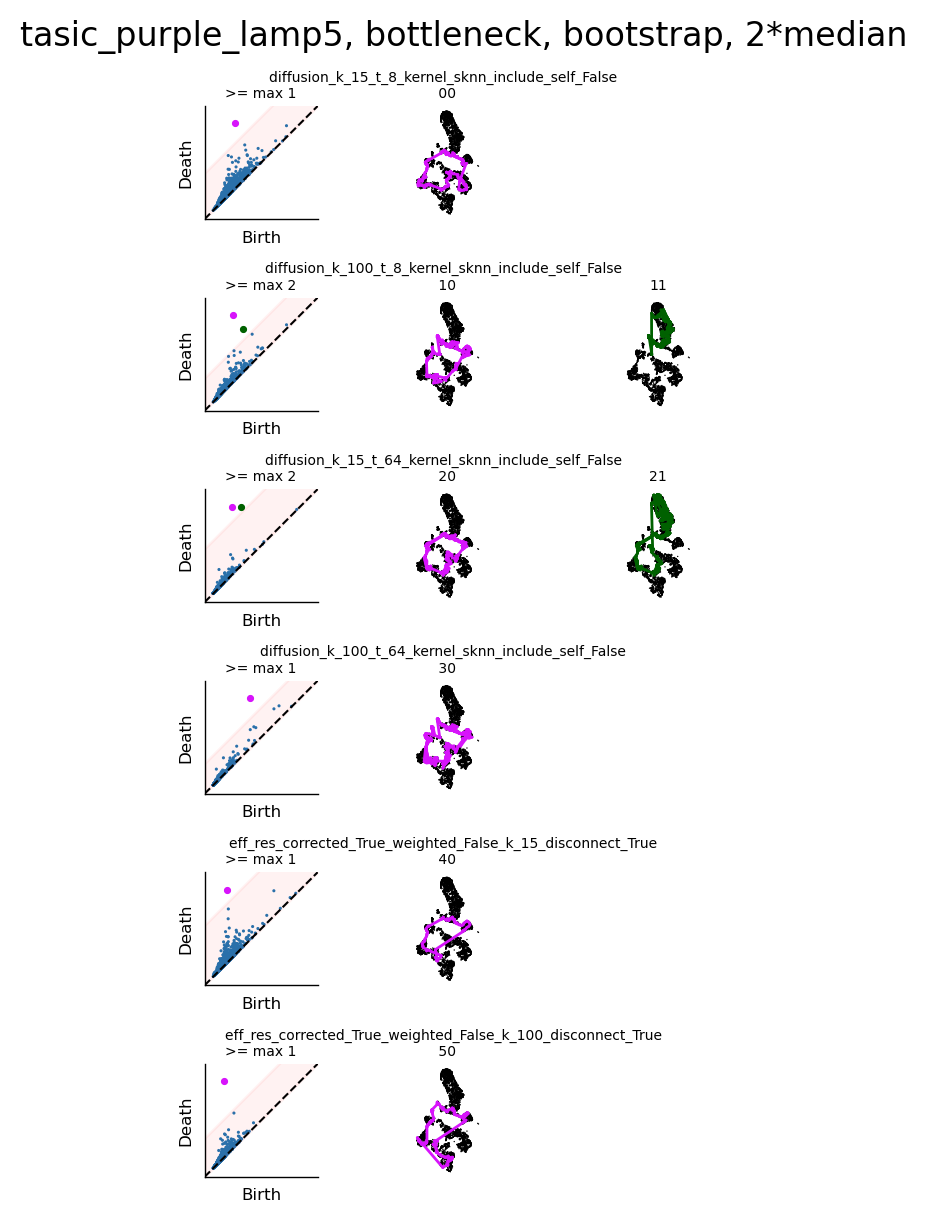

In [ ]:
geq_maxs = fig_bottleneck_median_scale(all_res, dataset=dataset, embd_n_mask =  embd_tasic_purple, method="bootstrap", scale = 2, save = False)
dist = distribution_max(all_res, cell_group_name= dataset, clusters = cluster_purple, full_d = full_d, mask = mask_purple, geq_maxs = geq_maxs)
save_dict(dist, os.path.join(get_path("data"),"final_dist_bottleneck_median_scale", f"dist_tasic_purple_scale_2.pkl"))